# Business Problem Statement

A marketing company wants to determine whether showing advertisements increases customer conversions compared to PSA (Public Service Announcement) campaigns.

The company conducted an A/B test:

Ad Group → users shown advertisements

PSA Group → users shown non-promotional messages

# The objective of this analysis is to:

Compare conversion rates

Identify whether ads improve conversions

Analyze user behavior by day and hour

Use statistical testing to validate results

Help the business make data-driven marketing decisions

# Dataset Description

Column	    Description

user id	:                      Unique customer identifier

test group	:                   Indicates Ad or PSA group

converted  :                     Whether user converted

total ads  :                   Total advertisements seen

most ads day  :	                      Day with highest ad exposure

most ads hour	:                    Hour with highest ad exposure

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

In [3]:
df = pd.read_csv("marketing_AB.csv")
df

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [4]:
df["test group"].unique()

array(['ad', 'psa'], dtype=object)

In [5]:
df =df.drop(columns = "Unnamed: 0")

In [6]:
df


,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...
588096,1278437,ad,False,1,Tuesday,23
588097,1327975,ad,False,1,Tuesday,23
588098,1038442,ad,False,3,Tuesday,23
588099,1496395,ad,False,1,Tuesday,23


In [7]:
df.describe()

,user id,total ads,most ads hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


In [9]:
df.isnull().sum()

user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

Null Values

No null values were found in the dataset, indicating the dataset is complete and reliable for analysis.



In [10]:
df.duplicated().sum()

np.int64(0)

Duplicate Values

No duplicate records were identified, ensuring data consistency and preventing biased results.

In [11]:
total_users = df['user id'].nunique()

print("Total Users:", total_users)

Total Users: 588101


Data contains 588101 total users

In [29]:
total_conversions = df['converted'].sum()

print("Total Conversions:", total_conversions)

Total Conversions: 14843


In [32]:
overall_conversion = df['converted'].mean() * 100

print("Overall Conversion Rate:", round(overall_conversion,2), "%")

Overall Conversion Rate: 2.52 %


In [35]:
conversion_rate = df.groupby(
    'test group'
)['converted'].mean() * 100

print(conversion_rate)

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64


2.55% of users converted by ad and 1.78% by psa

In [36]:
ad_rate = df[df['test group']=='ad'][
    'converted'
].mean()

psa_rate = df[df['test group']=='psa'][
    'converted'
].mean()

lift = ((ad_rate - psa_rate) / psa_rate) * 100

print("Conversion Lift:", round(lift,2), "%")

Conversion Lift: 43.09 %


Ads performed significantly better than the PSA group, increasing conversion rates by 43.01%.

In [33]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [34]:
df["converted"].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

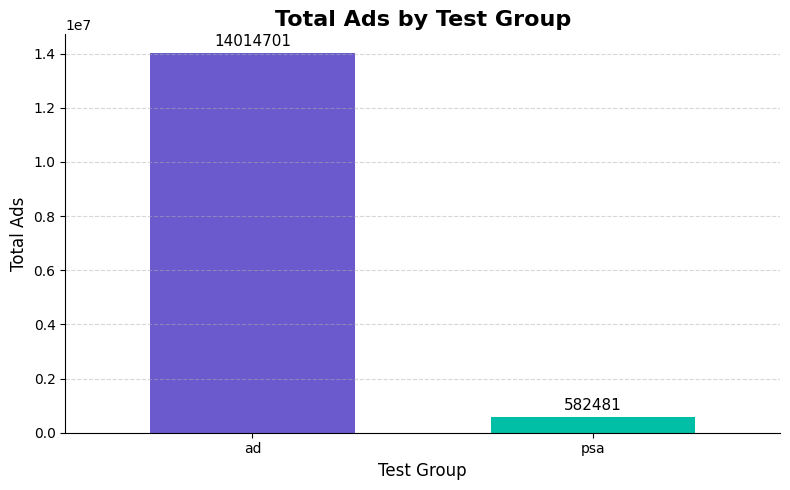

In [14]:
# Data
total_ads = df.groupby("test group")["total ads"].sum()

# Plot
ax = total_ads.plot(
    kind='bar',
    figsize=(8,5),
    color=['#6A5ACD', '#00BFA6'],
    width=0.6
)

# Titles & labels
plt.title("Total Ads by Test Group", fontsize=16, fontweight='bold')
plt.xlabel("Test Group", fontsize=12)
plt.ylabel("Total Ads", fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Rotate labels
plt.xticks(rotation=0)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=11, padding=3)

# Remove top/right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Advertisements were shown approximately 2306% more times than PSA campaigns.

In [15]:
df.groupby(["most ads day", "converted"]).size()

most ads day  converted
Friday        False        90551
              True          2057
Monday        False        84216
              True          2857
Saturday      False        79941
              True          1719
Sunday        False        83301
              True          2090
Thursday      False        81192
              True          1790
Tuesday       False        75167
              True          2312
Wednesday     False        78890
              True          2018
dtype: int64

In [57]:
day_group_rate = df.groupby(
    ['most ads day', 'test group']
)['converted'].mean() * 100

day_group_rate = day_group_rate.unstack()  # test group becomes columns

# Reorder days
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_group_rate = day_group_rate.reindex(days_order)

print(day_group_rate)

test group          ad       psa
most ads day                    
Monday        3.324120  2.255854
Tuesday       3.044038  1.444788
Wednesday     2.535586  1.575931
Thursday      2.163714  2.023047
Friday        2.246495  1.630292
Saturday      2.130657  1.399580
Sunday        2.461983  2.059497


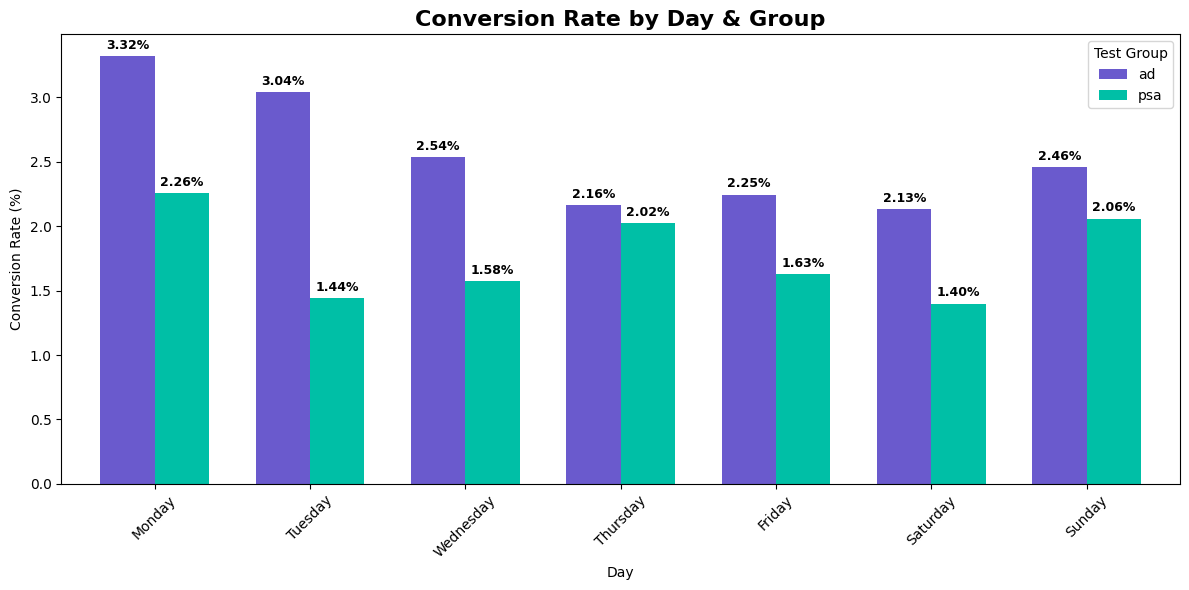

In [59]:
ax = day_group_rate.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#6A5ACD', '#00BFA6'],
    width=0.7
)
plt.title("Conversion Rate by Day & Group", fontsize=16, fontweight='bold')
plt.xlabel("Day")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Test Group")

# Add numbers on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=9, fontweight='bold', padding=3)

plt.tight_layout()
plt.show()

Ads outperform PSA every day of the week without exception.

Monday (3.32%) and Tuesday (3.04%) are the best days — prioritize ad spend here.

Tuesday has the biggest gap between ad and PSA (1.6%), meaning ads have the strongest individual impact on that day.

<Axes: xlabel='most ads hour'>

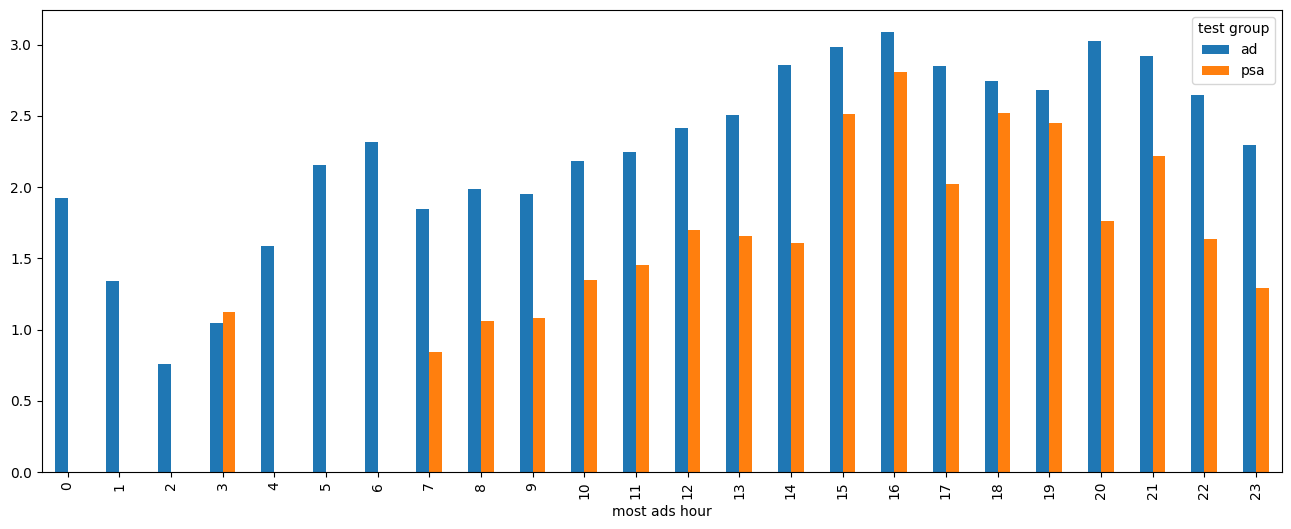

In [60]:
hour_group_rate = df.groupby(
    ['most ads hour', 'test group']
)['converted'].mean() * 100
hour_group_rate.unstack().plot(kind='bar', figsize=(16,6))

Ads outperform PSA at every hour of the day, confirming ads consistently drive better conversions.

Conversion rate peaks at 4 PM, making early afternoon the best time to run ad campaigns.

Early morning hours (1 AM – 6 AM) show the lowest rates for both groups, so running ads during these hours wastes budget.

In [18]:
# Conversion Rate Analysis

df["converted"].mean()* 100

np.float64(2.523886203220195)

In [19]:
# Conversions by group 

conversions= df.groupby("test group")["converted"].sum()
conversions

test group
ad     14423
psa      420
Name: converted, dtype: int64

In [20]:
# Conversion rate by group 

conversion_rate = df.groupby("test group")["converted"].mean()*100
conversion_rate

test group
ad     2.554656
psa    1.785411
Name: converted, dtype: float64

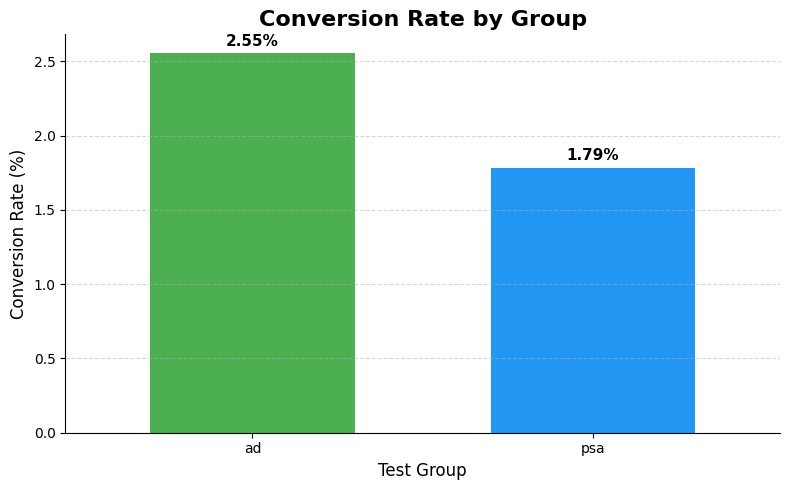

In [21]:
# Custom colors
colors = ['#4CAF50', '#2196F3']

# Plot
conversion_rate.plot(
    kind='bar',
    figsize=(8,5),
    color=colors,
    width=0.6
)

# Titles and labels
plt.title("Conversion Rate by Group", fontsize=16, fontweight='bold')
plt.xlabel("Test Group", fontsize=12)
plt.ylabel("Conversion Rate (%)", fontsize=12)

# Grid styling
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Rotate x labels
plt.xticks(rotation=0)

# Add percentage labels
for i, v in enumerate(conversion_rate):
    plt.text(i, v + 0.05, f"{v:.2f}%", 
             ha='center', fontsize=11, fontweight='bold')

# Remove top/right borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Although advertisements increased the conversion rate by 0.76%, achieving this improvement required millions of ad impressions.

This suggests that while ads positively impact conversions, the overall gain is relatively small compared to the scale of ad exposure.


# Hypothesis condition

Null Hypothesis (H₀)

Ads do NOT improve conversion rate.

Alternative Hypothesis (H₁)

Ads improve conversion rate.

# Statistical Interpretation

If p-value < 0.05:

Reject Null Hypothesis
Ads significantly improved conversions

If p-value > 0.05:

Fail to reject Null Hypothesis
No statistically significant improvement found

In [22]:
contingency = pd.crosstab(
    df['test group'],
    df['converted']
)

print(contingency)

converted    False  True 
test group               
ad          550154  14423
psa          23104    420


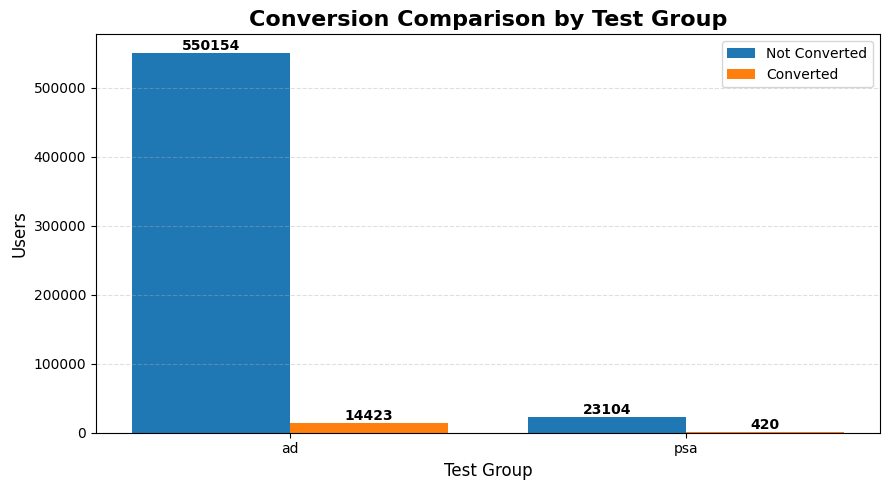

In [23]:
# Separate values
not_converted = contingency[False]
converted = contingency[True]

# Plot
fig, ax = plt.subplots(figsize=(9,5))

x = range(len(contingency.index))

# Bars
bars1 = ax.bar(
    x,
    not_converted,
    width=0.4,
    label='Not Converted'
)

bars2 = ax.bar(
    [i + 0.4 for i in x],
    converted,
    width=0.4,
    label='Converted'
)

# Labels
ax.set_title("Conversion Comparison by Test Group", fontsize=16, weight='bold')
ax.set_xlabel("Test Group", fontsize=12)
ax.set_ylabel("Users", fontsize=12)

# X ticks
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(contingency.index)

# Add values on top
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            weight='bold'
        )

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
plt.legend()

plt.tight_layout()
plt.show()

Chi-Square Test

The Chi-Square test checks whether conversion behavior is associated with the test group.

If the p-value is less than 0.05, we conclude that advertisements significantly impact conversions.

In [24]:
chi2,p,dof,expected = chi2_contingency(contingency)
print("P-Value :",p)

P-Value : 1.9989623063390075e-13


In [66]:
if p < 0.05 :
    print("Reject the null hypothesis")
    print("Ads significantly improve conversions")
else:
    print("We fail to reject null hypothesis")
    print("No significiant Improvement")

Reject the null hypothesis
Ads significantly improve conversions


Z-Test

The Z-Test compares the conversion rates between two groups.

This helps validate whether the observed difference happened due to chance or due to advertising impact.

# Z-test

In [27]:
# Success conversions
success = df.groupby(
    'test group'
)['converted'].sum().values.astype(int)

# Total observations
nobs = df.groupby(
    'test group'
)['converted'].count().values.astype(int)

# Z-test
z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [ ]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Ads significantly improved conversions")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant improvement")

Reject Null Hypothesis
Ads significantly improved conversions


In [63]:
# Conversion rate

ads_rate = df[df["test group"]=="ad"]["converted"].mean()
psa_rate = df[df["test group"]=="psa"]["converted"].mean()

print("ads_rate :",ads_rate)
print("psa_rate :",psa_rate)

ads_rate : 0.025546559636683747
psa_rate : 0.01785410644448223


In [40]:
# Sample sizes
n_ads = df[df['test group'] == 'ad'].shape[0]
n_psa = df[df['test group'] == 'psa'].shape[0]

print(n_ads, n_psa)

564577 23524


In [45]:
# conversion rate diff
diff = ads_rate-psa_rate
print("Difference:", diff)

Difference: 0.007692453192201517


In [64]:
# Standard error >> A measure of how much the result can change because of random variation.

Se = np.sqrt(
    (ads_rate *(1-ads_rate)/n_ads)+
    (psa_rate*(1-psa_rate)/n_psa)
)

print("Standard Error:", Se)

Standard Error: 0.0008885473275669375


In [49]:
lower = diff - 1.96 * Se
upper = diff + 1.96 * Se

print("95% Confidence Interval:")
print(lower, upper)

95% Confidence Interval:
0.00595090043017032 0.009434005954232714


Although ads performed better than the PSA campaign, the conversion increase was relatively small compared to the massive ad exposure required. With a 95% confidence interval ranging from 0.59% to 0.94%, the campaign appears effective, but not highly efficient at scale

The A/B testing analysis shows that advertisement campaigns generated higher conversions compared to PSA campaigns.

Statistical testing confirmed that the difference in conversion rates is significant and not due to random chance.

This suggests that advertisements positively influence customer conversion behavior and should remain part of the company’s marketing strategy.

# Business Recommendations


Continue running advertisement campaigns — ads drove a 43% higher conversion lift over PSA.

Optimize ad timing — focus budget between 12 PM – 6 PM, peaking at 4 PM.

Focus campaigns on high-performing days — prioritize Monday and Tuesday where conversion rates hit 3.32% and 3.04%.

Conduct further segmentation analysis to understand which user segments convert best.

Test different ad creatives for better performance.